# IQ Data Exploration

This notebook provides a visual tour of the synthetic IQ readout data produced
by `generate_iq_data` (CPU / NumPy) and `generate_iq_data_gpu` (GPU / CuPy).

**Contents**

| Section | Description |
|---------|-------------|
| **(a)** | Load default parameters from `config/default_params.json` |
| **(b)** | Generate 10 000 samples with each backend |
| **(c)** | Scatter plot colour-coded by qubit label |
| **(d)** | Per-class histograms projected onto *I* and *Q* axes |
| **(e)** | Annotate blob centres and 1σ / 2σ covariance ellipses |
| **(f)** | Sweep SNR from 1.0 → 6.0 and show how blob overlap decreases |

---
## Imports & helpers

In [1]:
import sys, json, copy, warnings, timeit
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors

# Ensure the src package is importable when running from notebooks/
SRC_DIR = str(Path("../src").resolve())
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from iq_simulator import generate_iq_data, generate_iq_data_gpu

# Try importing CuPy for GPU array handling
try:
    import cupy as cp
    _CUPY_AVAILABLE = True
except ImportError:
    _CUPY_AVAILABLE = False

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#3a3f4b",
    "axes.labelcolor": "#c9d1d9",
    "axes.grid": True,
    "grid.color": "#21262d",
    "grid.alpha": 0.6,
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "text.color": "#c9d1d9",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family": "sans-serif",
    "font.size": 11,
})

# Colour palette — cyan for |0⟩, magenta for |1⟩
C0, C1 = "#00d4ff", "#ff6ec7"
C0_DIM, C1_DIM = "#00a5cc80", "#cc589f80"


def _to_numpy(arr):
    """Convert CuPy array → NumPy (no-op if already NumPy)."""
    if _CUPY_AVAILABLE and isinstance(arr, cp.ndarray):
        return arr.get()
    return np.asarray(arr)


print("Imports OK.  CuPy available:", _CUPY_AVAILABLE)

Imports OK.  CuPy available: True


---
## (a) Load default parameters

In [2]:
config_path = Path("../config/default_params.json").resolve()
with open(config_path) as f:
    params = json.load(f)

print("Loaded parameters from:", config_path)
for k, v in params.items():
    print(f"  {k:20s} = {v}")

Loaded parameters from: /home/woolyhead/repos/CUDAQ_Examples/readout_classifier/config/default_params.json
  SNR                  = 3.0
  sigma                = 1.0
  p_thermal            = 0.02
  T1_over_tmeas        = 10.0
  blob_angle           = 0.0
  n_train              = 10000
  n_test               = 2000
  seed                 = 42


---
## (b) Generate 10 000 samples — CPU & GPU

In [5]:
N_SAMPLES = 10_000

# --- CPU (NumPy) ---
iq_cpu, labels_cpu = generate_iq_data(N_SAMPLES, params)
print(f"CPU  — iq shape: {iq_cpu.shape}, labels shape: {labels_cpu.shape}")
print(f"       label counts: |0⟩ = {np.sum(labels_cpu == 0)}, |1⟩ = {np.sum(labels_cpu == 1)}")

# --- GPU (CuPy) ---
iq_gpu_raw, labels_gpu_raw = generate_iq_data_gpu(N_SAMPLES, params)
iq_gpu = _to_numpy(iq_gpu_raw)
labels_gpu = _to_numpy(labels_gpu_raw)
print(f"\nGPU  — iq shape: {iq_gpu.shape}, labels shape: {labels_gpu.shape}")
print(f"       label counts: |0⟩ = {np.sum(labels_gpu == 0)}, |1⟩ = {np.sum(labels_gpu == 1)}")

CPU  — iq shape: (10000, 2), labels shape: (10000,)
       label counts: |0⟩ = 5061, |1⟩ = 4939

GPU  — iq shape: (10000, 2), labels shape: (10000,)
       label counts: |0⟩ = 5008, |1⟩ = 4992


---
## (c) Scatter plot — colour-coded by label

Side-by-side scatter plots for CPU and GPU generated data.

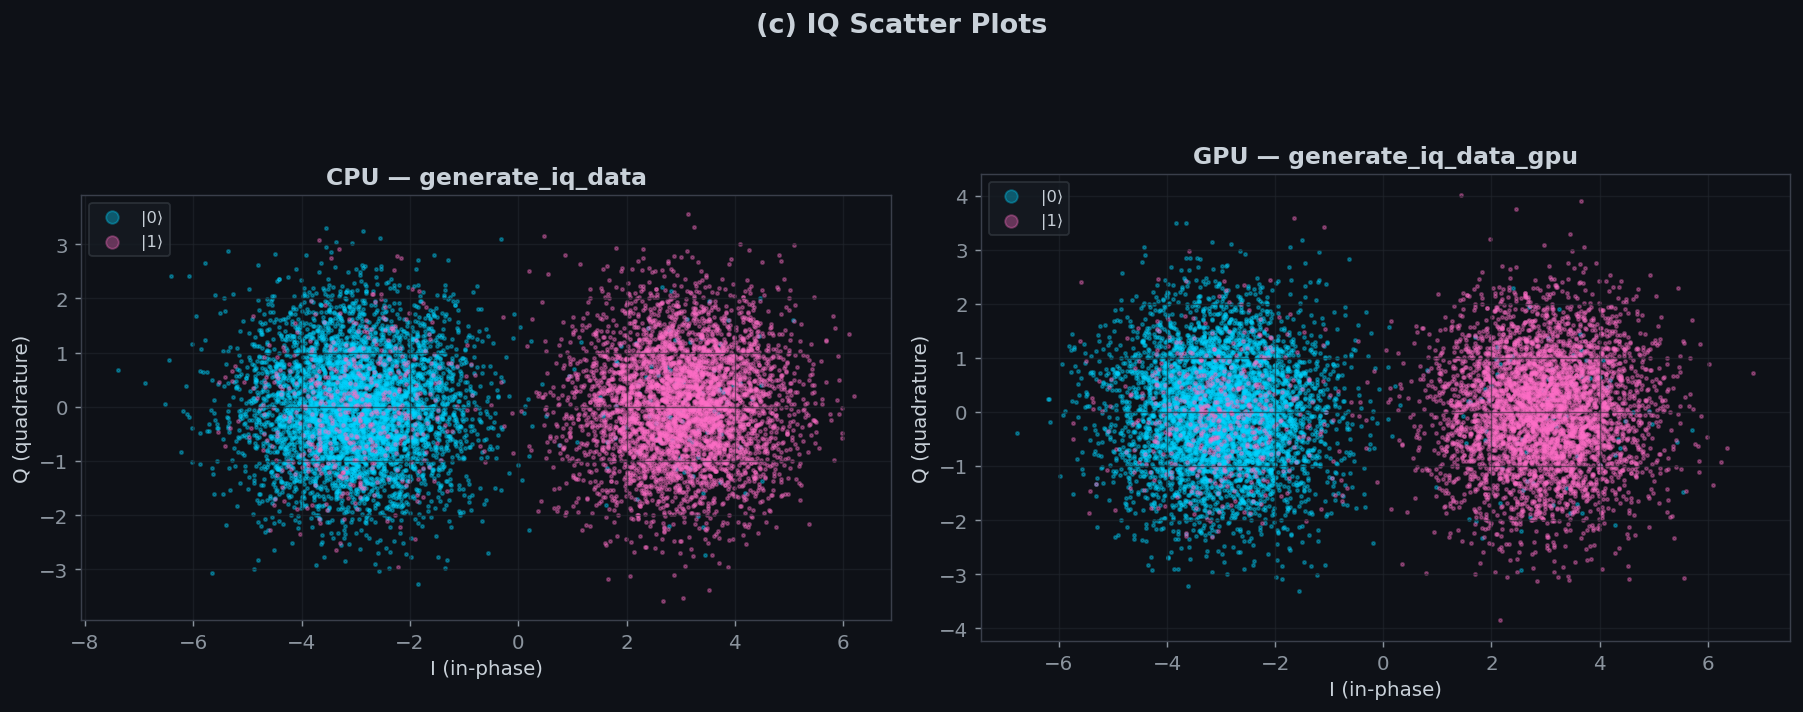

In [6]:
def scatter_iq(ax, iq, labels, title):
    """Draw a scatter plot of IQ data, coloured by label."""
    mask0 = labels == 0
    mask1 = labels == 1
    ax.scatter(iq[mask0, 0], iq[mask0, 1], s=3, alpha=0.35, c=C0, label="|0⟩", rasterized=True)
    ax.scatter(iq[mask1, 0], iq[mask1, 1], s=3, alpha=0.35, c=C1, label="|1⟩", rasterized=True)
    ax.set_xlabel("I (in-phase)")
    ax.set_ylabel("Q (quadrature)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", markerscale=4, fontsize=9)
    ax.set_aspect("equal")


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
scatter_iq(axes[0], iq_cpu, labels_cpu, "CPU — generate_iq_data")
scatter_iq(axes[1], iq_gpu, labels_gpu, "GPU — generate_iq_data_gpu")
fig.suptitle("(c) IQ Scatter Plots", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## (d) Per-class histograms projected onto I and Q axes

For each backend, we show marginal histograms of *I* and *Q* for class 0 and class 1.

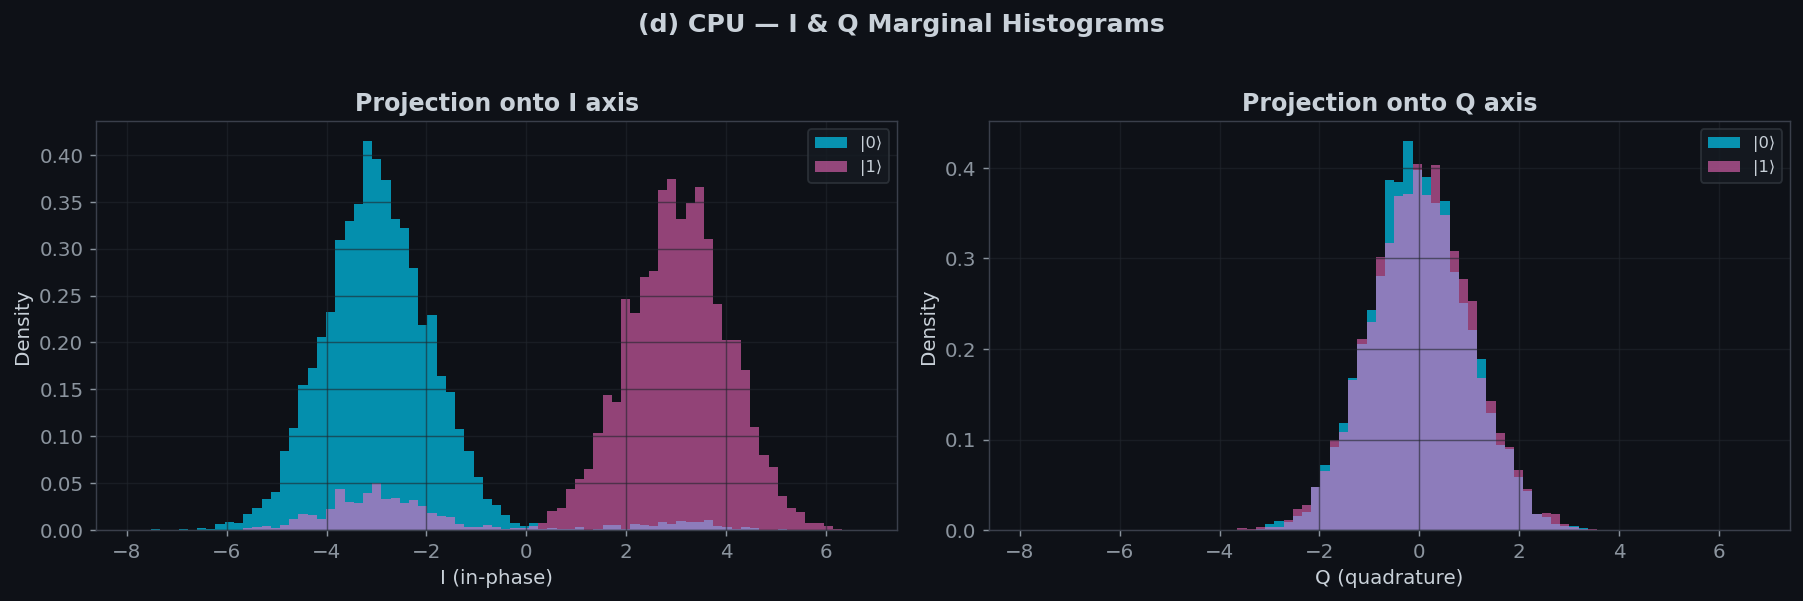

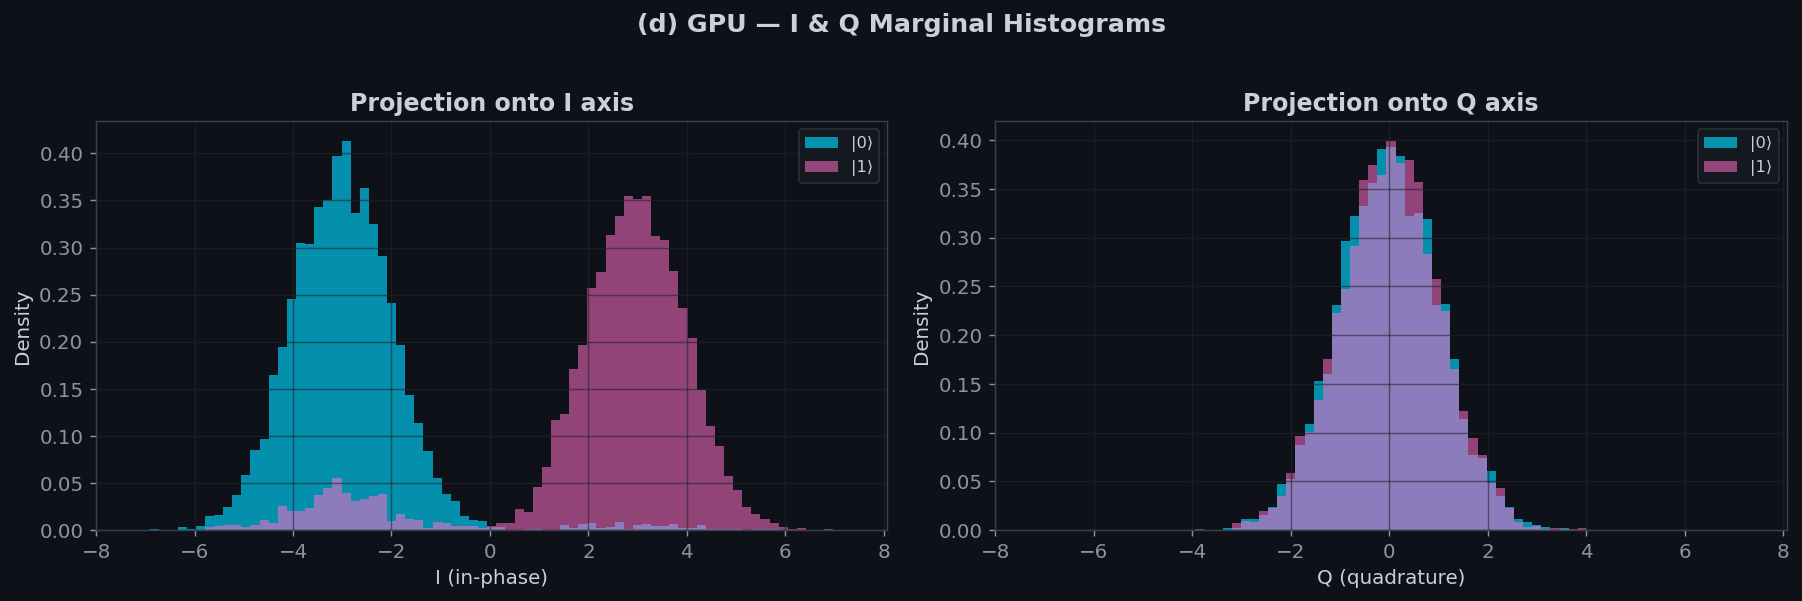

In [7]:
def hist_projections(iq, labels, suptitle):
    """Plot per-class histograms projected onto I and Q axes."""
    mask0 = labels == 0
    mask1 = labels == 1

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    bins = np.linspace(iq.min() - 0.5, iq.max() + 0.5, 80)

    # --- I-axis histogram ---
    axes[0].hist(iq[mask0, 0], bins=bins, alpha=0.65, color=C0, label="|0⟩", density=True)
    axes[0].hist(iq[mask1, 0], bins=bins, alpha=0.55, color=C1, label="|1⟩", density=True)
    axes[0].set_xlabel("I (in-phase)")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Projection onto I axis", fontweight="bold")
    axes[0].legend(fontsize=9)

    # --- Q-axis histogram ---
    axes[1].hist(iq[mask0, 1], bins=bins, alpha=0.65, color=C0, label="|0⟩", density=True)
    axes[1].hist(iq[mask1, 1], bins=bins, alpha=0.55, color=C1, label="|1⟩", density=True)
    axes[1].set_xlabel("Q (quadrature)")
    axes[1].set_ylabel("Density")
    axes[1].set_title("Projection onto Q axis", fontweight="bold")
    axes[1].legend(fontsize=9)

    fig.suptitle(suptitle, fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()


hist_projections(iq_cpu, labels_cpu, "(d) CPU — I & Q Marginal Histograms")
hist_projections(iq_gpu, labels_gpu, "(d) GPU — I & Q Marginal Histograms")

---
## (e) Annotate blob centres and σ-ellipses

We compute the empirical mean and covariance per class, then overlay
1σ and 2σ ellipses on the scatter plot.

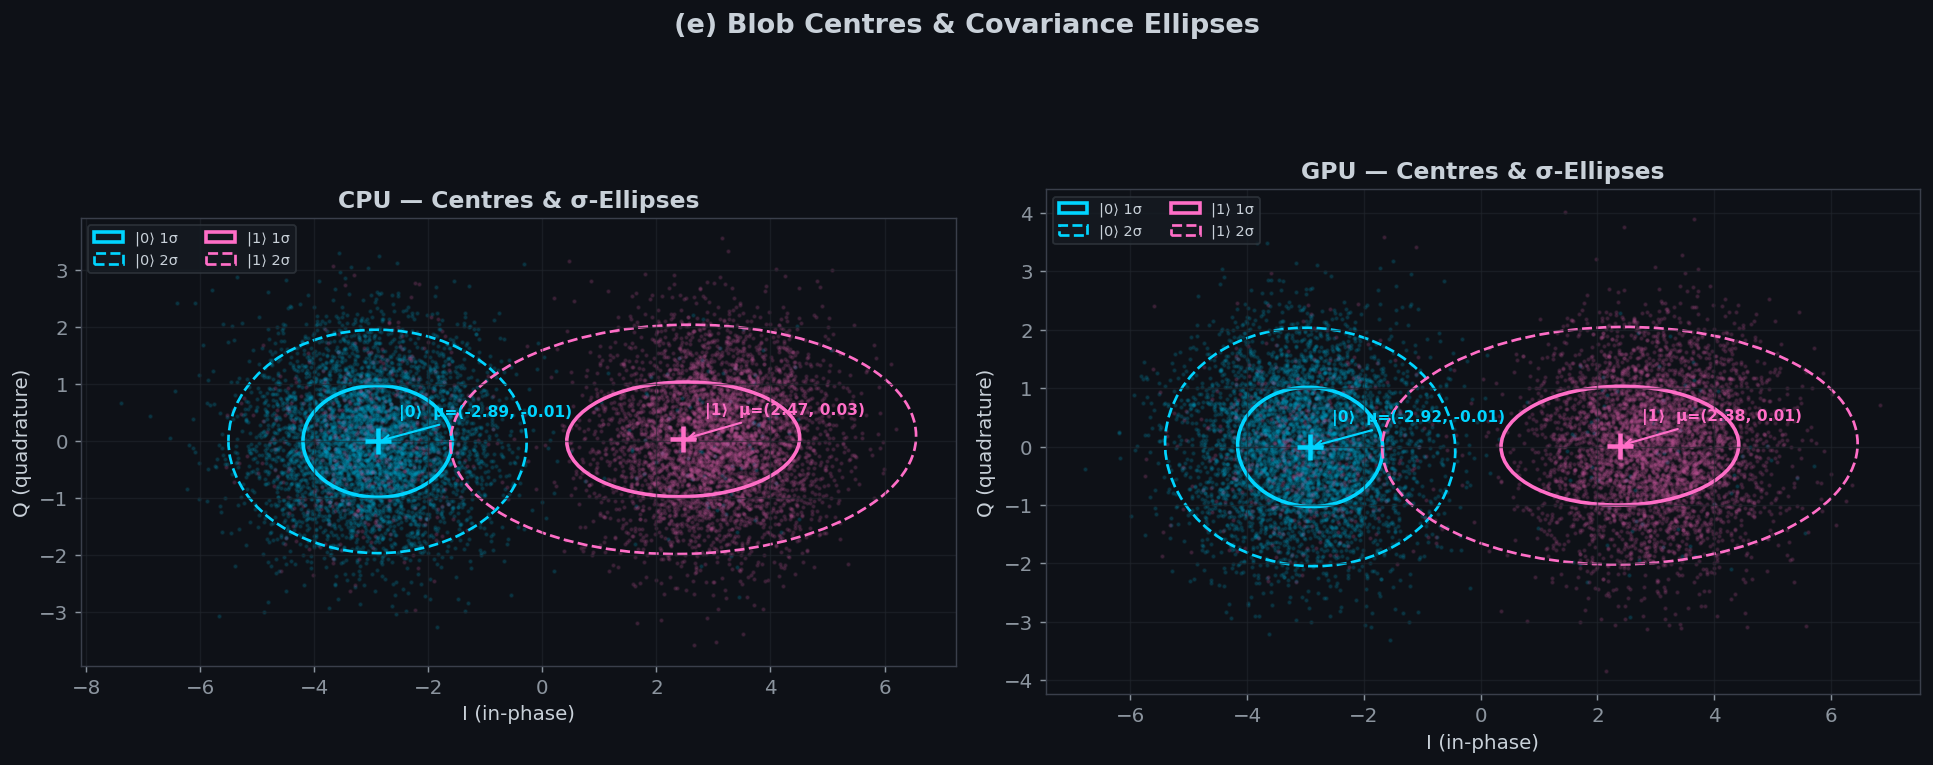

In [8]:
def covariance_ellipse(mean, cov, n_std=1.0, **kwargs):
    """Return a matplotlib Ellipse patch for a 2-D Gaussian."""
    eigvals, eigvecs = np.linalg.eigh(cov)
    # Angle of the first eigenvector
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    # Width and height = 2 * n_std * sqrt(eigenvalue)
    width, height = 2 * n_std * np.sqrt(eigvals)
    return Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)


def scatter_with_ellipses(ax, iq, labels, title):
    """Scatter plot with blob centres, 1σ and 2σ ellipses."""
    mask0 = labels == 0
    mask1 = labels == 1

    # Scatter (dimmed for legibility)
    ax.scatter(iq[mask0, 0], iq[mask0, 1], s=2, alpha=0.15, c=C0_DIM, rasterized=True)
    ax.scatter(iq[mask1, 0], iq[mask1, 1], s=2, alpha=0.15, c=C1_DIM, rasterized=True)

    for mask, colour, label_name in [(mask0, C0, "|0⟩"), (mask1, C1, "|1⟩")]:
        pts = iq[mask]
        mu = pts.mean(axis=0)
        cov = np.cov(pts.T)

        # Centre marker
        ax.plot(*mu, marker="+", ms=14, mew=2.5, color=colour, zorder=5)
        ax.annotate(
            f"{label_name}  μ=({mu[0]:.2f}, {mu[1]:.2f})",
            xy=mu, xytext=(12, 14), textcoords="offset points",
            fontsize=8.5, color=colour, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=colour, lw=1.2),
        )

        # 1σ ellipse (solid)
        e1 = covariance_ellipse(mu, cov, n_std=1.0,
                                 fill=False, edgecolor=colour, lw=2, ls="-", label=f"{label_name} 1σ")
        ax.add_patch(e1)

        # 2σ ellipse (dashed)
        e2 = covariance_ellipse(mu, cov, n_std=2.0,
                                 fill=False, edgecolor=colour, lw=1.5, ls="--", label=f"{label_name} 2σ")
        ax.add_patch(e2)

    ax.set_xlabel("I (in-phase)")
    ax.set_ylabel("Q (quadrature)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.set_aspect("equal")


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatter_with_ellipses(axes[0], iq_cpu, labels_cpu, "CPU — Centres & σ-Ellipses")
scatter_with_ellipses(axes[1], iq_gpu, labels_gpu, "GPU — Centres & σ-Ellipses")
fig.suptitle("(e) Blob Centres & Covariance Ellipses", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## (f) SNR sweep — blob overlap vs. SNR

We sweep SNR from 1.0 to 6.0 and plot the resulting scatter + ellipses side by
side for both CPU and GPU generators. As SNR increases, the blob separation
grows relative to the blob width, making classification easier.

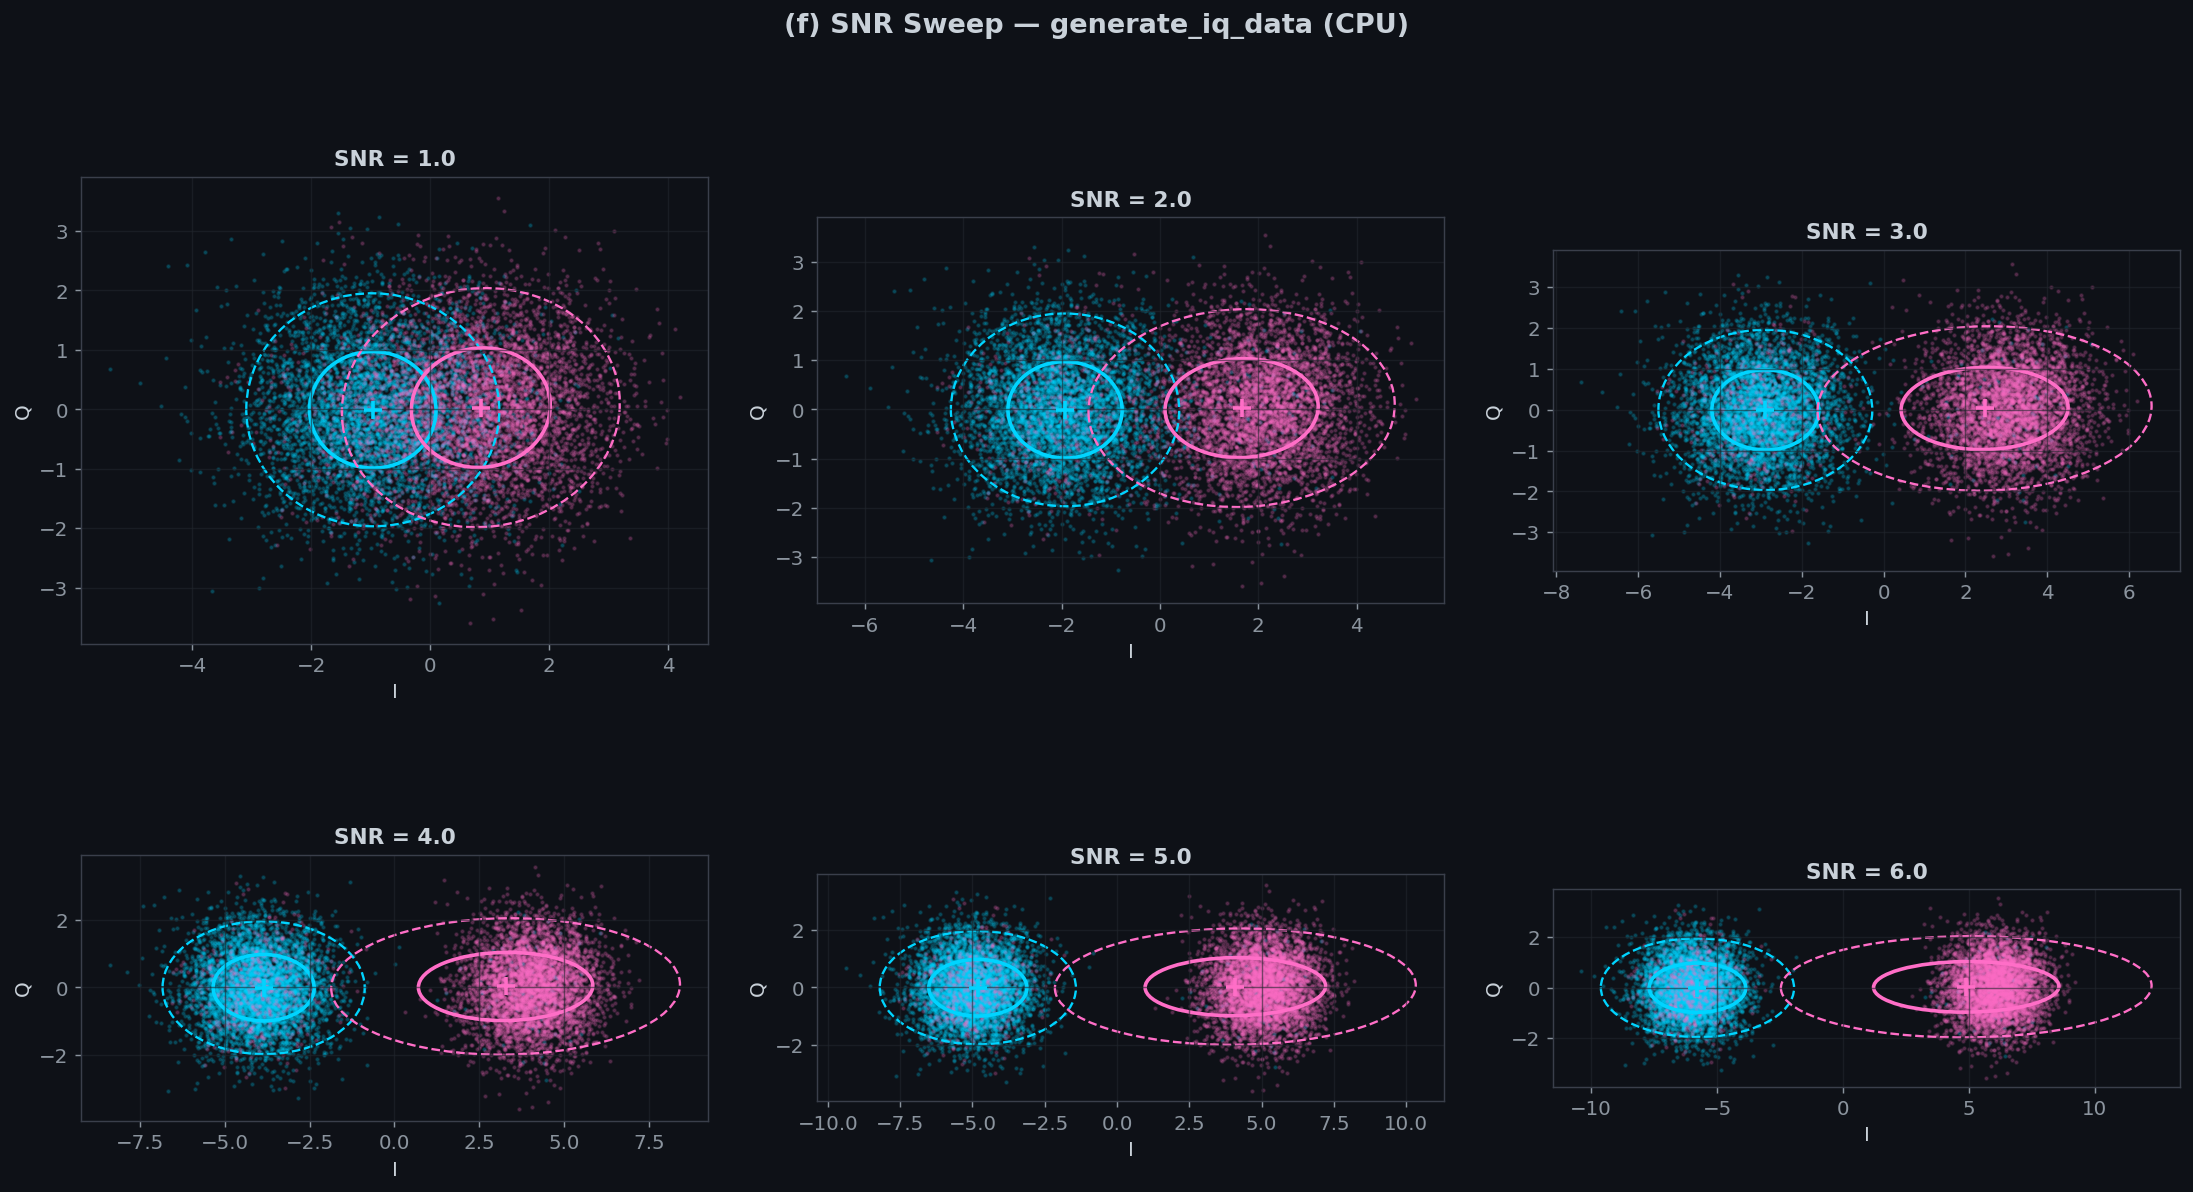

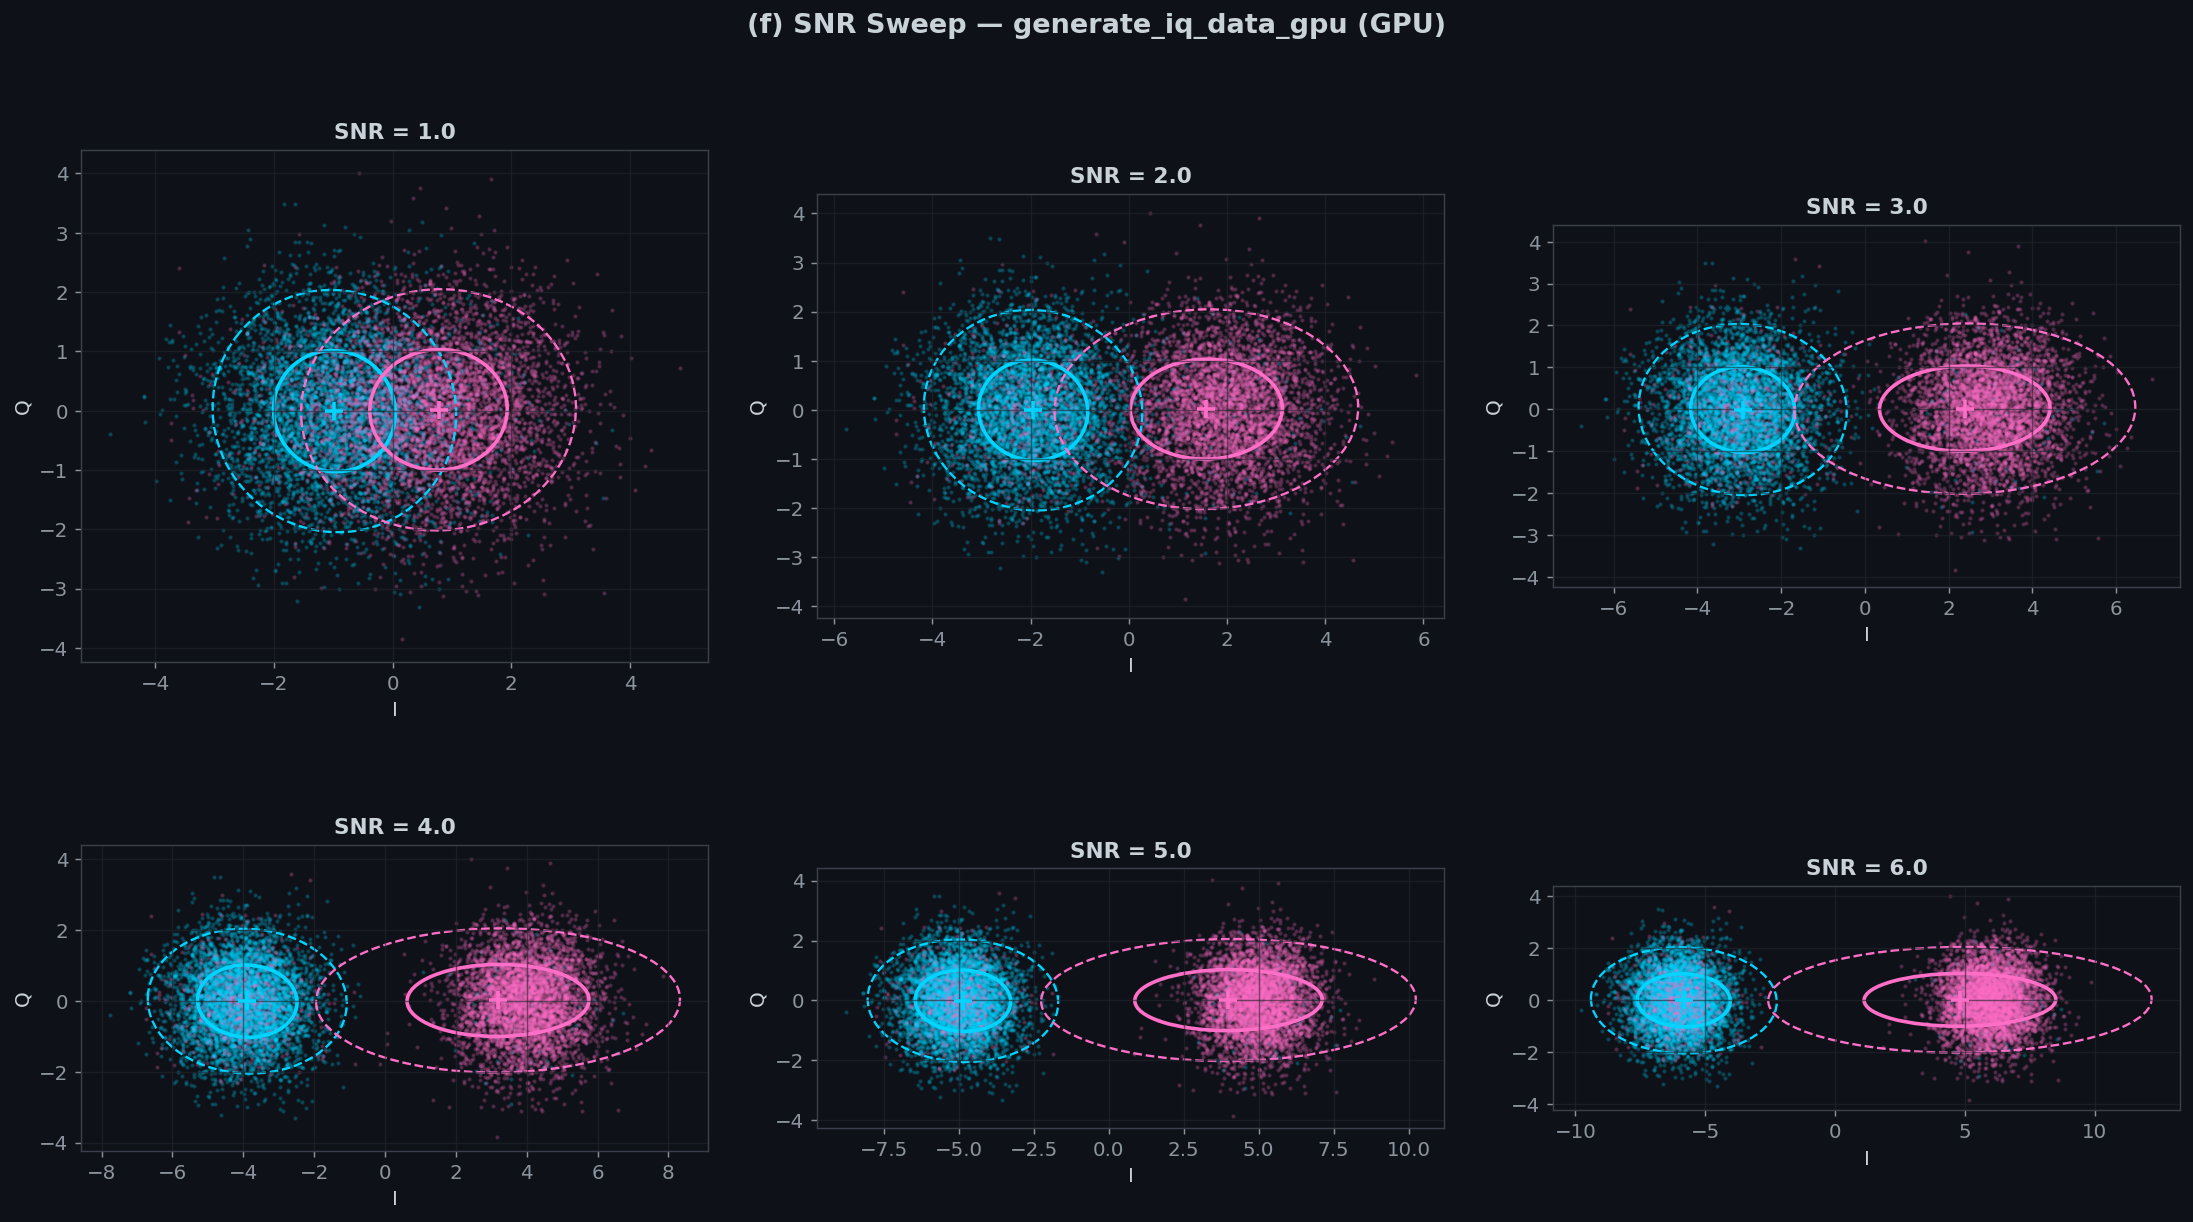

In [9]:
snr_values = np.arange(1.0, 6.5, 1.0)  # [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
n_snr = len(snr_values)


def plot_snr_sweep(generator_fn, backend_label, convert_fn=lambda x: x):
    """Generate data at each SNR and plot scatter + 1σ/2σ ellipses."""
    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    axes = axes.ravel()

    for idx, snr_val in enumerate(snr_values):
        sweep_params = copy.deepcopy(params)
        sweep_params["SNR"] = float(snr_val)

        iq_raw, lbl_raw = generator_fn(N_SAMPLES, sweep_params)
        iq_np = convert_fn(iq_raw)
        lbl_np = convert_fn(lbl_raw)

        ax = axes[idx]
        mask0 = lbl_np == 0
        mask1 = lbl_np == 1

        ax.scatter(iq_np[mask0, 0], iq_np[mask0, 1], s=2, alpha=0.18, c=C0, rasterized=True)
        ax.scatter(iq_np[mask1, 0], iq_np[mask1, 1], s=2, alpha=0.18, c=C1, rasterized=True)

        for mask, colour in [(mask0, C0), (mask1, C1)]:
            pts = iq_np[mask]
            mu = pts.mean(axis=0)
            cov = np.cov(pts.T)
            ax.plot(*mu, marker="+", ms=10, mew=2, color=colour, zorder=5)
            for ns, ls, lw in [(1.0, "-", 2), (2.0, "--", 1.3)]:
                e = covariance_ellipse(mu, cov, n_std=ns,
                                        fill=False, edgecolor=colour, lw=lw, ls=ls)
                ax.add_patch(e)

        ax.set_title(f"SNR = {snr_val:.1f}", fontsize=12, fontweight="bold")
        ax.set_xlabel("I")
        ax.set_ylabel("Q")
        ax.set_aspect("equal")

    fig.suptitle(
        f"(f) SNR Sweep — {backend_label}",
        fontsize=15, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    plt.show()


# --- CPU sweep ---
plot_snr_sweep(generate_iq_data, "generate_iq_data (CPU)")

# --- GPU sweep ---
plot_snr_sweep(generate_iq_data_gpu, "generate_iq_data_gpu (GPU)", convert_fn=_to_numpy)

---
### Observations

* At **SNR ≈ 1**, the two blobs overlap heavily — a classifier can do little
  better than chance.
* By **SNR ≈ 3** (the default), the blobs are well-separated but the tails
  still overlap, providing a realistic test-bed for the VQC classifier.
* At **SNR ≥ 5**, the blobs are essentially disjoint — even a simple threshold
  on *I* classifies almost perfectly.

The GPU generator produces statistically identical distributions (same model,
different RNG stream).

---
## (g) Randomised blob angles — IQ-plane rotation

In a real experiment the readout axis in the IQ plane depends on the
local-oscillator frequency relative to the resonator.  A non-zero
`blob_angle` rotates **both** the blob centres and the covariance
structure.  Here we draw 6 random angles from *U(−π, π)* and plot
the resulting distributions for both backends.


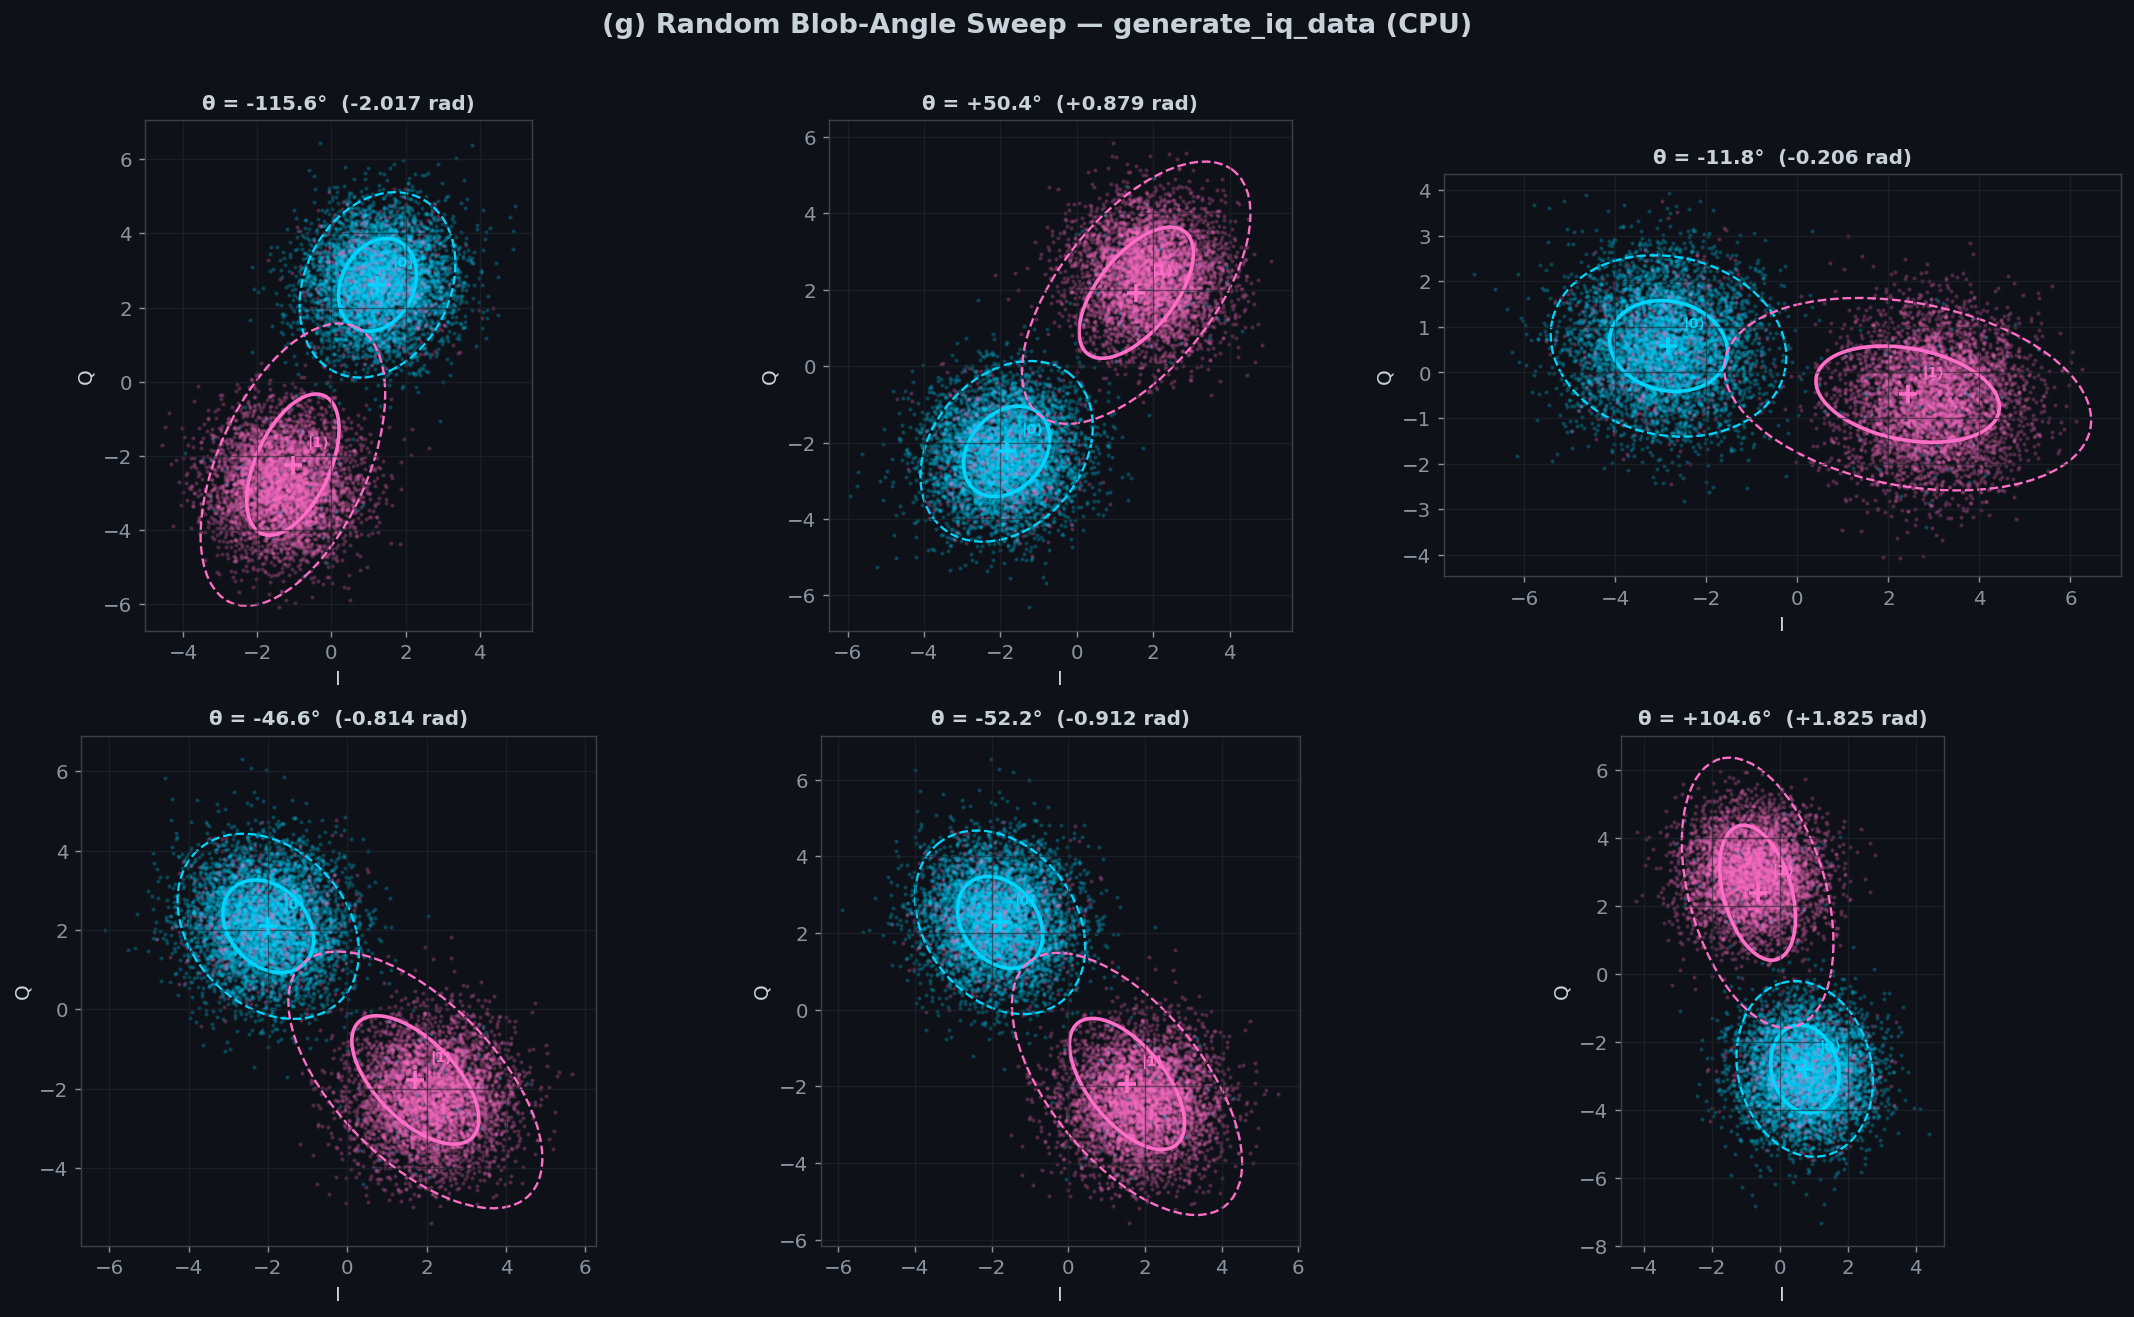

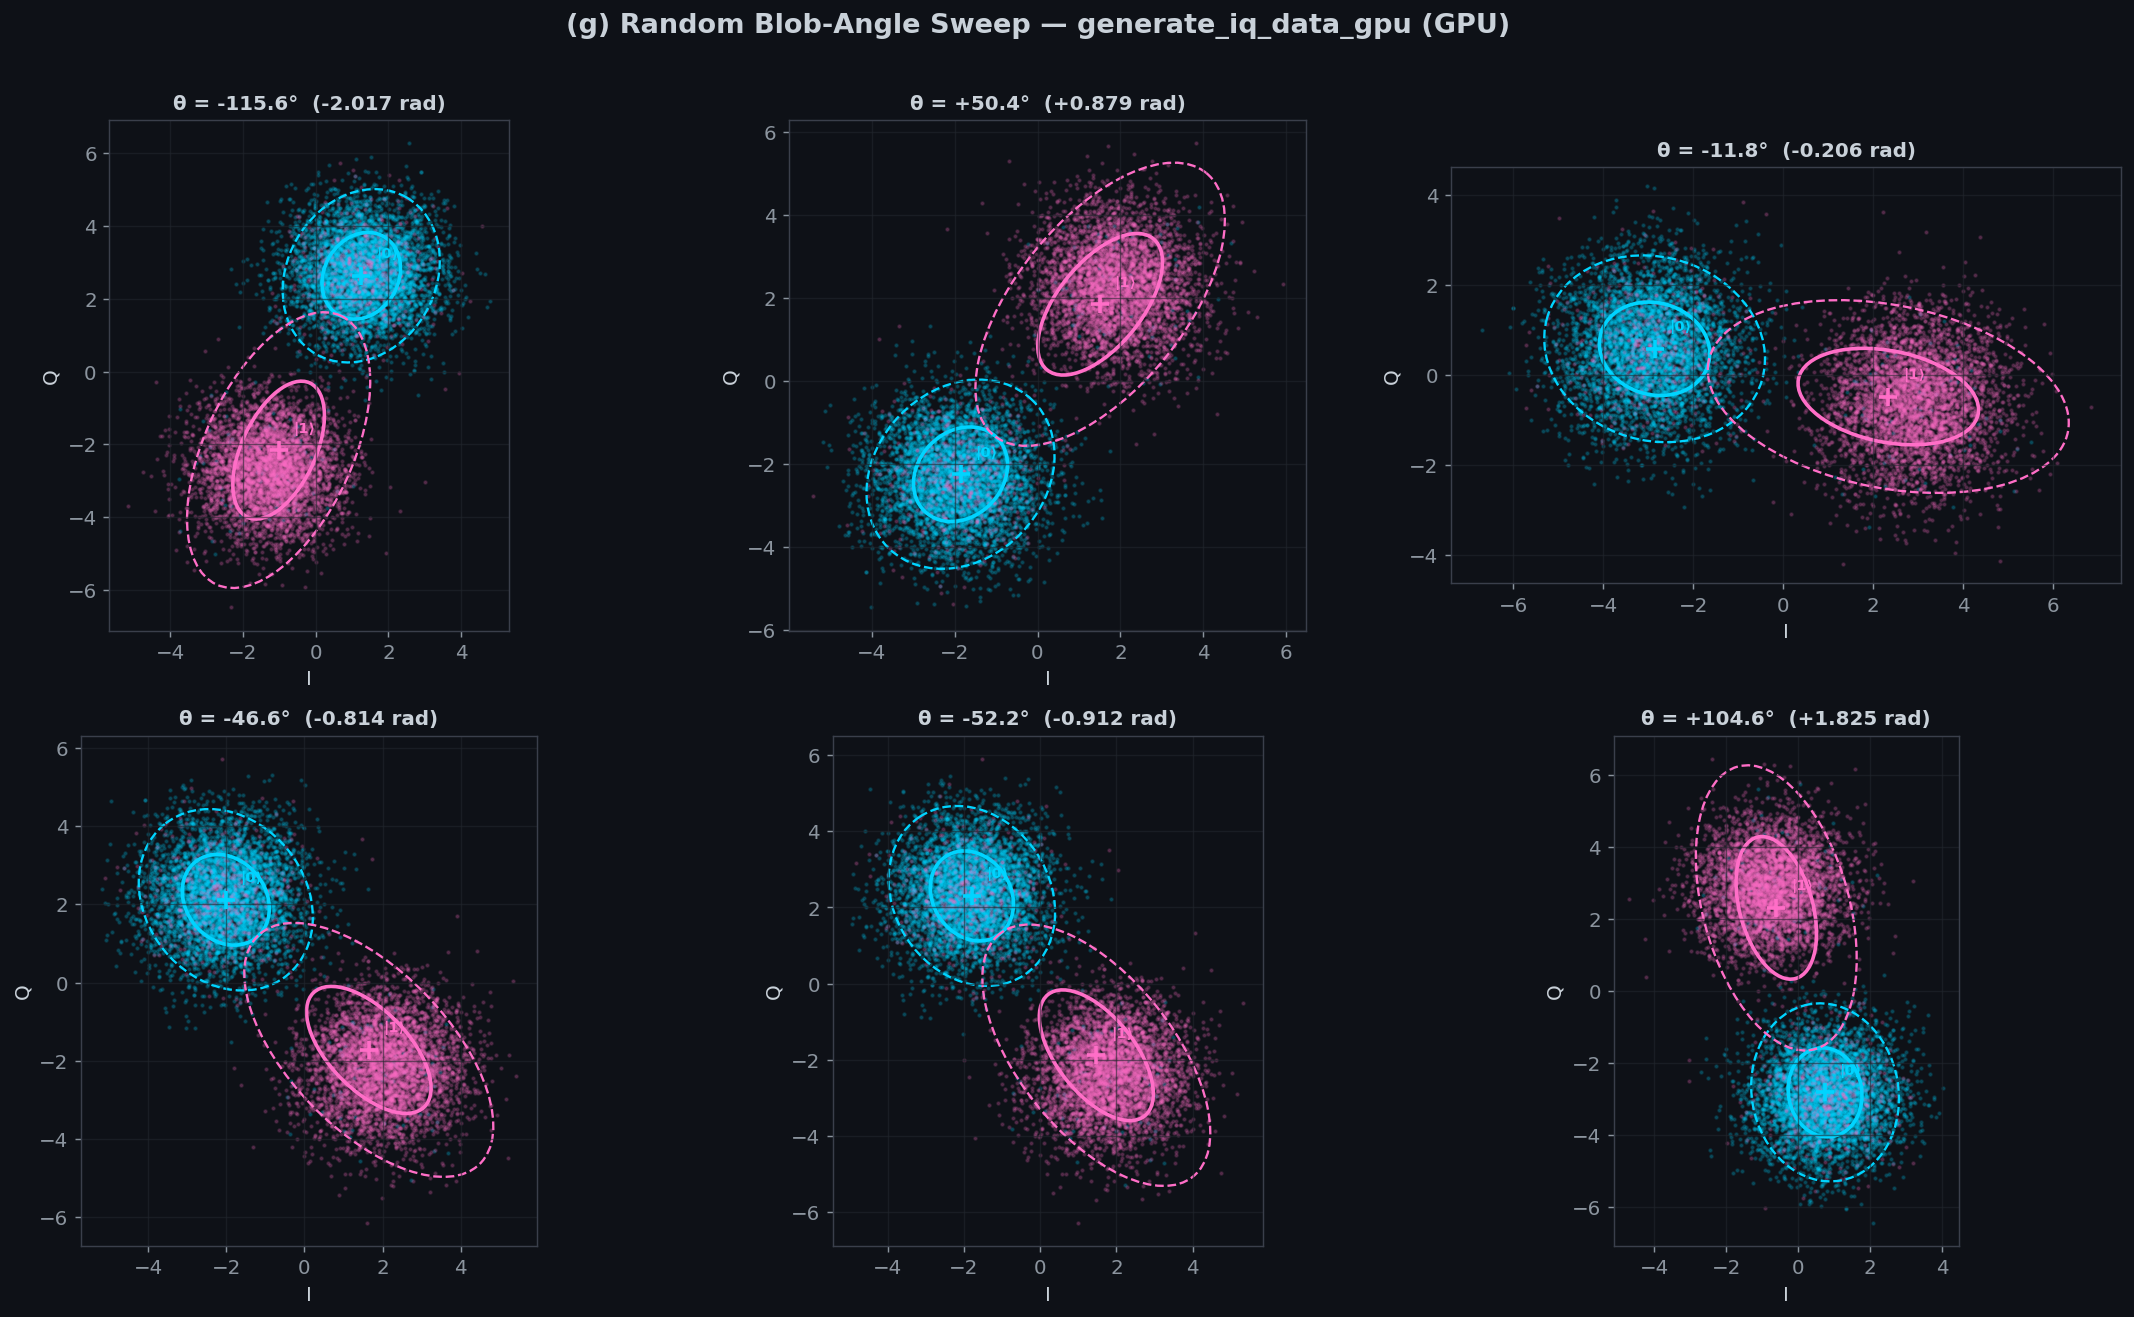

In [10]:
# Reproducible random angles drawn uniformly from (-π, π)
angle_rng = np.random.default_rng(2026)
random_angles = angle_rng.uniform(-np.pi, np.pi, size=6)


def plot_angle_sweep(generator_fn, backend_label, convert_fn=lambda x: x):
    """Generate data at each random blob_angle and plot scatter + ellipses."""
    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    axes = axes.ravel()

    for idx, angle in enumerate(random_angles):
        angle_params = copy.deepcopy(params)
        angle_params["blob_angle"] = float(angle)

        iq_raw, lbl_raw = generator_fn(N_SAMPLES, angle_params)
        iq_np = convert_fn(iq_raw)
        lbl_np = convert_fn(lbl_raw)

        ax = axes[idx]
        mask0 = lbl_np == 0
        mask1 = lbl_np == 1

        ax.scatter(iq_np[mask0, 0], iq_np[mask0, 1], s=2, alpha=0.18,
                   c=C0, rasterized=True)
        ax.scatter(iq_np[mask1, 0], iq_np[mask1, 1], s=2, alpha=0.18,
                   c=C1, rasterized=True)

        for mask, colour, lbl_name in [(mask0, C0, "|0⟩"), (mask1, C1, "|1⟩")]:
            pts = iq_np[mask]
            mu = pts.mean(axis=0)
            cov = np.cov(pts.T)
            ax.plot(*mu, marker="+", ms=10, mew=2, color=colour, zorder=5)
            ax.annotate(
                f"{lbl_name}",
                xy=mu, xytext=(8, 10), textcoords="offset points",
                fontsize=8, color=colour, fontweight="bold",
            )
            for ns, ls, lw in [(1.0, "-", 2), (2.0, "--", 1.3)]:
                e = covariance_ellipse(mu, cov, n_std=ns,
                                        fill=False, edgecolor=colour, lw=lw, ls=ls)
                ax.add_patch(e)

        ax.set_title(f"θ = {np.degrees(angle):+.1f}°  ({angle:+.3f} rad)",
                     fontsize=11, fontweight="bold")
        ax.set_xlabel("I")
        ax.set_ylabel("Q")
        ax.set_aspect("equal")

    fig.suptitle(
        f"(g) Random Blob-Angle Sweep — {backend_label}",
        fontsize=15, fontweight="bold", y=1.01,
    )
    fig.tight_layout()
    plt.show()


# --- CPU angle sweep ---
plot_angle_sweep(generate_iq_data, "generate_iq_data (CPU)")

# --- GPU angle sweep ---
plot_angle_sweep(generate_iq_data_gpu, "generate_iq_data_gpu (GPU)", convert_fn=_to_numpy)
